# 05 — Model Fusion: concat vs penjumlahan adaptif, plus Oracle

Tahap 6. **Belum pernah dijalankan** di mesin penulis kode. Jalankan di mesin
compute.

**Prasyarat:** `01`–`04` sudah dijalankan. Notebook ini membutuhkan
`manifest.csv`, `split_seed*.json`, `sequences_500x300_fp16.npy`, dan
`pred_text_seed*.npy` + `pred_image_seed*.npy` dari kedua baseline.

## Yang diuji

1. FUSION dengan konkatenasi — strategi yang dipakai paper
2. FUSION dengan penjumlahan adaptif — paper melaporkan ini **gagal**, kita uji sendiri
3. **Oracle** dari kedua baseline standalone, batas atas teoretis fusion
4. Tabel setara Tabel 3 paper: OA dan F1 per kelas untuk TEXT / IMAGE / FUSION / Oracle

Hyperparameter paper §4.2: SGD momentum 0,9, lr 0,01, batch 40, **200 epoch**.

> **Peringatan durasi.** Model fusion memuat MobileNetV2 384x384 **dan** CNN1D
> sekaligus, jadi lebih berat dari baseline citra. Dua strategi x 3 seed x 200 epoch.
> Jalankan sel estimasi dulu.

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score

from src import datasets as DS
from src import splits as S
from src import train as T
from src.config import CONFIG, set_seed
from src.models import STRATEGIES, FusionModel, build_transform
from src.utils import save_fig

manifest = pd.read_csv(CONFIG["data_processed"] / "manifest.csv")
labels = manifest["kelas"].tolist()
y = DS.label_indices(labels)
device = T.pick_device()
transform = build_transform()
seq_path = CONFIG["data_processed"] / "sequences_500x300_fp16.npy"
print(f"{len(manifest)} dokumen | device: {device} | strategi: {STRATEGIES}")

3482 dokumen | device: cuda | strategi: ('concat', 'sum')


## 1. Data berpasangan

`PairDataset` menyatukan citra dan teks dokumen yang sama. Ia meng-assert label
kedua sisi cocok di setiap sampel — kalau urutan indeksnya berbeda, model akan tetap
berlatih tanpa error sambil memasangkan dokumen yang salah.

In [2]:
def buat_pasangan(idx):
    img = DS.ImageDataset(manifest["path_citra"].tolist(), y, idx, transform)
    txt = DS.SequenceDataset(seq_path, y, idx)
    return DS.PairDataset(img, txt)

set_seed(42)
split = S.load_split(42, labels)
loaders = DS.make_loaders(buat_pasangan, split, num_workers=CONFIG["num_workers"])

(xb_img, xb_txt), yb = next(iter(loaders["train"]))
print("citra:", tuple(xb_img.shape), "| teks:", tuple(xb_txt.shape),
      "| label:", tuple(yb.shape))
assert xb_img.shape[1:] == (3, CONFIG["image_size"], CONFIG["image_size"])
assert xb_txt.shape[1:] == (CONFIG["embedding_dim"], CONFIG["max_words"])

citra: (8, 3, 384, 384) | teks: (8, 300, 500) | label: (8,)


## 2. Estimasi durasi

In [3]:
est = T.estimate_duration(FusionModel(strategy="concat"), loaders,
                          CONFIG["epochs"]["fusion"], device=device)
print(json.dumps(est, indent=2))
total = est["perkiraan_jam"] * 3 * len(STRATEGIES)
print(f"\n{est['perkiraan_jam']} jam per run -> {total:.1f} jam untuk "
      f"{len(STRATEGIES)} strategi x 3 seed.")
print("\nKalau tidak masuk anggaran: turunkan EPOCHS, atau kurangi SEEDS untuk "
      "strategi 'sum' saja (paper pun hanya menyebutnya sebagai eksperimen "
      "pendahuluan). Catat pemotongannya sebagai deviasi eksplisit.")

{
  "detik_per_epoch": 75.6645,
  "target_epochs": 200,
  "perkiraan_detik": 15132.9,
  "perkiraan_menit": 252.22,
  "perkiraan_jam": 4.2,
  "device": "cuda"
}

4.2 jam per run -> 25.2 jam untuk 2 strategi x 3 seed.

Kalau tidak masuk anggaran: turunkan EPOCHS, atau kurangi SEEDS untuk strategi 'sum' saja (paper pun hanya menyebutnya sebagai eksperimen pendahuluan). Catat pemotongannya sebagai deviasi eksplisit.


In [4]:
# Tidak ada yang perlu diatur di sini — lihat notebook 04.
from src.config import deviasi_runtime

EPOCHS = CONFIG["epochs"]["fusion"]
SEEDS = CONFIG["seeds"]
DEVIASI = deviasi_runtime()

print(f"{EPOCHS} epoch x {len(SEEDS)} seed x {len(STRATEGIES)} strategi"
      + (f" | micro-batch {CONFIG['micro_batch_size']}"
         if CONFIG["micro_batch_size"] else ""))
print("\nDeviasi yang dipaksa mesin ini — SALIN ke catatan eksperimen:")
for d in DEVIASI:
    print(f"  - {d}")
if not DEVIASI:
    print("  tidak ada; setelan persis seperti paper")

200 epoch x 3 seed x 2 strategi | micro-batch 8

Deviasi yang dipaksa mesin ini — SALIN ke catatan eksperimen:
  - batch 40 dipecah jadi micro-batch 8 dengan akumulasi gradien; update optimizer tetap dari 40 sampel, tapi BatchNorm menormalisasi per micro-batch
  - mixed precision (AMP) aktif, tidak dipakai paper


## 3. Latih kedua strategi

Dilatih end-to-end. Cabang citra mulai dari bobot ImageNet seperti baseline IMAGE,
cabang teks mulai dari nol — itu bacaan kita atas "trained end-to-end", dan paper
tidak menyatakannya eksplisit.

**Risiko yang perlu diperhatikan di log:** satu cabang pretrained dilatih bersama
satu cabang dari nol pada lr yang sama. Kalau cabang teks belum sempat belajar
apa pun sementara cabang citra sudah konvergen, fusion bisa runtuh jadi
model citra dengan parameter ekstra. Untuk strategi `sum`, bobot cabang yang
dicetak tiap run adalah indikator langsung: kalau bobot teks mendekati nol,
itulah yang terjadi.

In [5]:
hasil, prediksi, bobot_cabang = [], {}, {}

for strategy in STRATEGIES:
    for seed in SEEDS:
        set_seed(seed)
        sp = S.load_split(seed, labels)
        ld = DS.make_loaders(buat_pasangan, sp, num_workers=CONFIG["num_workers"])
        model = FusionModel(strategy=strategy, pretrained_image=True)

        print(f"\n[FUSION-{strategy} seed {seed}]")
        res = T.train_model(
            model, ld, epochs=EPOCHS, device=device,
            log_csv=CONFIG["root"] / "reports" / f"log_FUSION-{strategy}_seed{seed}.csv",
            ckpt_path=CONFIG["models"] / f"FUSION-{strategy}_seed{seed}.pt")
        ev = T.evaluate(model, ld["test"], device)

        if strategy == "sum":
            w = model.branch_weights().detach().cpu().numpy()
            bobot_cabang[seed] = {"citra": float(w[0]), "teks": float(w[1])}
            print(f"  bobot terlatih -> citra {w[0]:.3f}, teks {w[1]:.3f}")

        hasil.append({"strategi": strategy, "seed": seed,
                      "oa": round(ev["oa"], 4),
                      "macro_f1": round(ev["macro_f1"], 4),
                      "epoch_terbaik": res["best_epoch"],
                      "epoch_dijalankan": res["epochs_run"],
                      "durasi_detik": res["durasi_detik"]})
        prediksi[(strategy, seed)] = ev

df = pd.DataFrame(hasil)
display(df)


[FUSION-concat seed 42]
  epoch   1/200  train_loss 2.0534  val_oa 0.5125  (76.8s)
  epoch  10/200  train_loss 0.2815  val_oa 0.8000  (75.9s)
  epoch  20/200  train_loss 0.1249  val_oa 0.8125  (77.5s)
  epoch  30/200  train_loss 0.0703  val_oa 0.8375  (75.7s)
  early stopping di epoch 33; terbaik epoch 18

[FUSION-concat seed 43]
  epoch   1/200  train_loss 2.0842  val_oa 0.5375  (75.7s)
  epoch  10/200  train_loss 0.3094  val_oa 0.8625  (74.8s)
  epoch  20/200  train_loss 0.1048  val_oa 0.9000  (77.8s)
  epoch  30/200  train_loss 0.0654  val_oa 0.9375  (75.9s)
  epoch  40/200  train_loss 0.0596  val_oa 0.9000  (71.8s)
  early stopping di epoch 46; terbaik epoch 31

[FUSION-concat seed 44]
  epoch   1/200  train_loss 1.9767  val_oa 0.4750  (75.2s)
  epoch  10/200  train_loss 0.3266  val_oa 0.7750  (74.5s)
  epoch  20/200  train_loss 0.1367  val_oa 0.7875  (73.0s)
  epoch  30/200  train_loss 0.1452  val_oa 0.8250  (74.6s)
  epoch  40/200  train_loss 0.0529  val_oa 0.7875  (72.6s)
  epo

,strategi,seed,oa,macro_f1,epoch_terbaik,epoch_dijalankan,durasi_detik
0,concat,42,0.8218,0.8047,18,33,2544.346
1,concat,43,0.8475,0.8183,31,46,3457.262
2,concat,44,0.8333,0.8086,46,61,4493.131
3,sum,42,0.8043,0.7785,12,27,1973.356
4,sum,43,0.8389,0.8116,20,35,2525.832
5,sum,44,0.8393,0.8068,19,34,2509.790


In [6]:
ringkas = df.groupby("strategi").agg(
    oa_mean=("oa", "mean"), oa_std=("oa", lambda s: s.std(ddof=0)),
    f1_mean=("macro_f1", "mean"), f1_std=("macro_f1", lambda s: s.std(ddof=0)),
    jam=("durasi_detik", lambda s: s.sum() / 3600)).round(4)
display(ringkas)

for strategi, r in ringkas.iterrows():
    print(f"{strategi:7s}  OA {r['oa_mean']:.4f} +/- {r['oa_std']:.4f}   "
          f"macro F1 {r['f1_mean']:.4f} +/- {r['f1_std']:.4f}")

if bobot_cabang:
    print("\nBobot cabang terlatih (strategi sum):")
    display(pd.DataFrame(bobot_cabang).T.round(3))

,oa_mean,oa_std,f1_mean,f1_std,jam
strategi,,,,,
concat,0.8342,0.0105,0.8105,0.0057,2.9152
sum,0.8275,0.0164,0.7990,0.0146,1.9469


concat   OA 0.8342 +/- 0.0105   macro F1 0.8105 +/- 0.0057
sum      OA 0.8275 +/- 0.0164   macro F1 0.7990 +/- 0.0146

Bobot cabang terlatih (strategi sum):


,citra,teks
42,0.694,0.306
43,0.685,0.315
44,0.691,0.309


## 4. Apakah penjumlahan benar-benar gagal?

Paper melaporkan penjumlahan "jatuh signifikan di bawah baseline citra murni",
**tanpa angka dan tanpa menjelaskan apa yang membuatnya adaptif**. Kita memakai satu
skalar terlatih per cabang lewat softmax. Kesimpulan apa pun di bawah berlaku untuk
mekanisme itu, bukan untuk fusion penjumlahan sebagai kelas metode.

In [7]:
oa_img = np.array([np.load(CONFIG["data_processed"] / f"pred_image_seed{s}.npy")
                   for s in SEEDS])
oa_img = np.array([(p[1] == p[0]).mean() for p in oa_img])
baseline_citra = oa_img.mean()

concat = ringkas.loc["concat", "oa_mean"]
summed = ringkas.loc["sum", "oa_mean"]
print(f"baseline IMAGE    {baseline_citra:.4f}")
print(f"FUSION concat     {concat:.4f}   ({concat - baseline_citra:+.4f})")
print(f"FUSION sum        {summed:.4f}   ({summed - baseline_citra:+.4f})")

if summed < baseline_citra:
    print("\nPenjumlahan di bawah baseline citra — konsisten dengan laporan paper.")
    print("Tapi TULIS: konsisten untuk mekanisme yang KITA pilih, bukan replikasi "
          "temuan paper, karena paper tidak pernah menyebut mekanismenya.")
    print("Tag: #temuan/positif terhadap arah klaim paper.")
else:
    print("\nPenjumlahan TIDAK jatuh di bawah baseline citra.")
    print("Ini #temuan/negatif terhadap paper dan justru lebih menarik: kemungkinan "
          "kegagalan yang dilaporkan paper adalah artefak mekanisme mereka "
          "(mungkin rata-rata tanpa bobot terlatih), bukan sifat fusion penjumlahan.")
    print("Jangan dihaluskan jadi 'hasil kami sedikit berbeda'.")

baseline IMAGE    0.8086
FUSION concat     0.8342   (+0.0256)
FUSION sum        0.8275   (+0.0189)

Penjumlahan TIDAK jatuh di bawah baseline citra.
Ini #temuan/negatif terhadap paper dan justru lebih menarik: kemungkinan kegagalan yang dilaporkan paper adalah artefak mekanisme mereka (mungkin rata-rata tanpa bobot terlatih), bukan sifat fusion penjumlahan.
Jangan dihaluskan jadi 'hasil kami sedikit berbeda'.


## 5. Oracle

Dihitung dari prediksi per-sampel **dua baseline standalone** pada split test yang
sama — bukan dari cabang internal model fusion. Satu sampel benar bila TEXT **atau**
IMAGE benar.

Target paper: TEXT 73,8 / IMAGE 84,5 / FUSION 87,8 / **Oracle 92,1**. Artinya
potensi di atas baseline terbaik 7,6% absolut, dan fusion memanen 3,3% — sekitar 43%.

In [8]:
baris_oracle = []
pred_oracle = {}
for seed in SEEDS:
    t_true, t_pred = np.load(CONFIG["data_processed"] / f"pred_text_seed{seed}.npy")
    i_true, i_pred = np.load(CONFIG["data_processed"] / f"pred_image_seed{seed}.npy")
    assert np.array_equal(t_true, i_true), \
        f"seed {seed}: urutan test TEXT dan IMAGE berbeda — oracle tidak sah"

    orc = T.oracle(t_true, t_pred, i_pred)   # tie-break ke IMAGE, baseline terkuat
    pred_oracle[seed] = orc
    baris_oracle.append({
        "seed": seed,
        "oa_text": round((t_pred == t_true).mean(), 4),
        "oa_image": round((i_pred == i_true).mean(), 4),
        "oa_oracle": round(orc["oa"], 4),
        "f1_oracle": round(orc["macro_f1"], 4),
        "keduanya_benar": round(orc["keduanya_benar"], 4),
        "hanya_text": round(orc["hanya_a_benar"], 4),
        "hanya_image": round(orc["hanya_b_benar"], 4),
        "keduanya_salah": round(orc["keduanya_salah"], 4),
    })

df_orc = pd.DataFrame(baris_oracle)
display(df_orc)

,seed,oa_text,oa_image,oa_oracle,f1_oracle,keduanya_benar,hanya_text,hanya_image,keduanya_salah
0,42,0.7345,0.8315,0.9098,0.8968,0.6562,0.0783,0.1752,0.0902
1,43,0.7248,0.8136,0.8990,0.8898,0.6394,0.0854,0.1741,0.1010
2,44,0.7204,0.7808,0.8844,0.8683,0.6167,0.1037,0.1641,0.1156


In [9]:
oa_oracle = df_orc["oa_oracle"].mean()
terbaik = max(df_orc["oa_text"].mean(), df_orc["oa_image"].mean())
potensi = oa_oracle - terbaik
dipanen = concat - terbaik

print(f"baseline terbaik  {terbaik:.4f}")
print(f"oracle            {oa_oracle:.4f}")
print(f"potensi tersedia  {potensi:+.4f} absolut")
print(f"dipanen FUSION    {dipanen:+.4f} absolut")
if potensi > 0:
    print(f"\nFUSION memanen {dipanen / potensi:.0%} dari potensi yang tersedia.")
    print(f"Paper: 3,3% dari 7,6% = 43%.")
print(f"\nBagian yang tidak bisa diselamatkan skema pemilihan apa pun "
      f"(keduanya salah): {df_orc['keduanya_salah'].mean():.4f}")
print(f"Komplementaritas langsung (hanya TEXT benar): "
      f"{df_orc['hanya_text'].mean():.4f}")

baseline terbaik  0.8086
oracle            0.8977
potensi tersedia  +0.0891 absolut
dipanen FUSION    +0.0256 absolut

FUSION memanen 29% dari potensi yang tersedia.
Paper: 3,3% dari 7,6% = 43%.

Bagian yang tidak bisa diselamatkan skema pemilihan apa pun (keduanya salah): 0.1023
Komplementaritas langsung (hanya TEXT benar): 0.0891


## 6. Tabel utama — setara Tabel 3 paper

OA dan F1 per kelas untuk TEXT / IMAGE / FUSION / Oracle, dirata-ratakan atas seed.

In [10]:
def f1_per_kelas(y_true, y_pred):
    return f1_score(y_true, y_pred, average=None,
                    labels=range(len(CONFIG["classes"])), zero_division=0)

kolom = {}
for seed in SEEDS:
    t_true, t_pred = np.load(CONFIG["data_processed"] / f"pred_text_seed{seed}.npy")
    i_true, i_pred = np.load(CONFIG["data_processed"] / f"pred_image_seed{seed}.npy")
    kolom.setdefault("TEXT", []).append(f1_per_kelas(t_true, t_pred))
    kolom.setdefault("IMAGE", []).append(f1_per_kelas(i_true, i_pred))
    ev = prediksi[("concat", seed)]
    kolom.setdefault("FUSION", []).append(f1_per_kelas(ev["y_true"], ev["y_pred"]))
    o = pred_oracle[seed]
    kolom.setdefault("Oracle", []).append(f1_per_kelas(o["y_true"], o["y_pred"]))

tabel = pd.DataFrame({k: np.mean(v, axis=0) for k, v in kolom.items()},
                     index=CONFIG["classes"]).round(3)
oa_baris = pd.Series({
    "TEXT": df_orc["oa_text"].mean(), "IMAGE": df_orc["oa_image"].mean(),
    "FUSION": concat, "Oracle": oa_oracle}).round(4)
tabel.loc["-- OA --"] = oa_baris
display(tabel)

paper = pd.DataFrame({
    "TEXT":   [0.60, 0.96, 0.76, 0.71, 0.79, 0.67, 0.62, 0.43, 0.97, 0.57],
    "IMAGE":  [0.94, 0.96, 0.85, 0.83, 0.90, 0.89, 0.83, 0.61, 0.80, 0.62],
    "FUSION": [0.93, 0.98, 0.88, 0.86, 0.90, 0.90, 0.85, 0.71, 0.96, 0.68],
    "Oracle": [0.94, 0.99, 0.94, 0.92, 0.93, 0.93, 0.89, 0.81, 0.97, 0.79],
}, index=CONFIG["classes"])
paper.loc["-- OA --"] = [0.738, 0.845, 0.878, 0.921]
print("\nTabel 3 paper, untuk dibandingkan:")
display(paper)
print("\nSelisih (kita - paper):")
display((tabel - paper).round(3))

,TEXT,IMAGE,FUSION,Oracle
Advertisement,0.5370,0.9020,0.8940,0.9300
Email,0.9530,0.9550,0.9610,0.9830
Form,0.7180,0.8040,0.8480,0.9020
Letter,0.6710,0.8050,0.8350,0.8980
Memo,0.7580,0.8440,0.8790,0.9200
News,0.7090,0.8900,0.8830,0.9380
Note,0.6210,0.7710,0.7800,0.8760
Report,0.4950,0.5270,0.6380,0.7350
Resume,0.9690,0.7840,0.8030,0.9510
Scientific,0.5870,0.5540,0.5830,0.7180



Tabel 3 paper, untuk dibandingkan:


,TEXT,IMAGE,FUSION,Oracle
Advertisement,0.600,0.940,0.930,0.940
Email,0.960,0.960,0.980,0.990
Form,0.760,0.850,0.880,0.940
Letter,0.710,0.830,0.860,0.920
Memo,0.790,0.900,0.900,0.930
News,0.670,0.890,0.900,0.930
Note,0.620,0.830,0.850,0.890
Report,0.430,0.610,0.710,0.810
Resume,0.970,0.800,0.960,0.970
Scientific,0.570,0.620,0.680,0.790



Selisih (kita - paper):


,TEXT,IMAGE,FUSION,Oracle
Advertisement,-0.063,-0.038,-0.036,-0.010
Email,-0.007,-0.005,-0.019,-0.007
Form,-0.042,-0.046,-0.032,-0.038
Letter,-0.039,-0.025,-0.025,-0.022
Memo,-0.032,-0.056,-0.021,-0.010
News,0.039,0.000,-0.017,0.008
Note,0.001,-0.059,-0.070,-0.014
Report,0.065,-0.083,-0.072,-0.075
Resume,-0.001,-0.016,-0.157,-0.019
Scientific,0.017,-0.066,-0.097,-0.072


In [11]:
# Klaim paper: fusion "hampir tidak pernah" di bawah salah satu baseline per kelas.
# Tabel 3 paper sendiri punya dua pengecualian (Resume, Advertisement). Periksa milik kita.
kelas = CONFIG["classes"]
kalah = []
for i, k in enumerate(kelas):
    f_t, f_i, f_f = tabel.loc[k, "TEXT"], tabel.loc[k, "IMAGE"], tabel.loc[k, "FUSION"]
    if f_f < max(f_t, f_i):
        kalah.append({"kelas": k, "FUSION": f_f, "TEXT": f_t, "IMAGE": f_i,
                      "selisih": round(f_f - max(f_t, f_i), 3)})
print(f"Kelas di mana FUSION di bawah baseline terbaiknya: {len(kalah)} dari 10")
if kalah:
    display(pd.DataFrame(kalah))
print("\nPaper punya 2 pengecualian: Resume (TEXT 0,97 > FUSION 0,96) dan "
      "Advertisement (IMAGE 0,94 > FUSION 0,93).")
print("Kalau jumlah kita jauh lebih banyak, itu #temuan/negatif yang harus "
      "dilaporkan apa adanya.")

Kelas di mana FUSION di bawah baseline terbaiknya: 4 dari 10


,kelas,FUSION,TEXT,IMAGE,selisih
0,Advertisement,0.894,0.537,0.902,-0.008
1,News,0.883,0.709,0.890,-0.007
2,Resume,0.803,0.969,0.784,-0.166
3,Scientific,0.583,0.587,0.554,-0.004



Paper punya 2 pengecualian: Resume (TEXT 0,97 > FUSION 0,96) dan Advertisement (IMAGE 0,94 > FUSION 0,93).
Kalau jumlah kita jauh lebih banyak, itu #temuan/negatif yang harus dilaporkan apa adanya.


               precision    recall  f1-score   support

Advertisement      0.925     0.904     0.914       177
        Email      0.975     0.948     0.961       461
         Form      0.751     0.919     0.827       332
       Letter      0.887     0.771     0.825       437
         Memo      0.907     0.812     0.857       478
         News      0.915     0.897     0.906       145
         Note      0.719     0.826     0.769       155
       Report      0.579     0.686     0.628       204
       Resume      0.899     0.772     0.830        92
   Scientific      0.524     0.537     0.531       201

     accuracy                          0.822      2682
    macro avg      0.808     0.807     0.805      2682
 weighted avg      0.833     0.822     0.824      2682


tabel utama disimpan ke reports/tabel_utama.csv


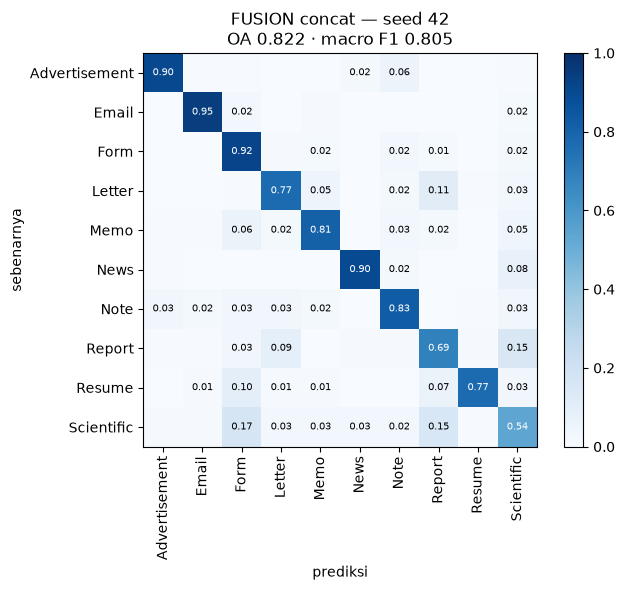

In [12]:
fig = T.plot_confusion(prediksi[("concat", SEEDS[0])],
                      f"FUSION concat — seed {SEEDS[0]}")
save_fig(fig, f"06_confusion_fusion_concat_seed{SEEDS[0]}")
print(T.report(prediksi[("concat", SEEDS[0])]))

tabel.to_csv(CONFIG["root"] / "reports" / "tabel_utama.csv")
print("\ntabel utama disimpan ke reports/tabel_utama.csv")

## 7. Ringkasan untuk catatan eksperimen

Satu catatan per strategi di `vault/30-eksperimen/`, plus
`vault/50-hasil/tabel-utama.md` yang menyatukan semuanya.

In [13]:
for strategi in STRATEGIES:
    sub = df[df["strategi"] == strategi]
    print(f"\n----- FUSION-{strategi} -----")
    for _, r in sub.iterrows():
        print(f"seed {int(r['seed'])}: oa:: {r['oa']}  macro_f1:: {r['macro_f1']}  "
              f"durasi:: {r['durasi_detik']}s")
    print(f"rata-rata: oa:: {sub['oa'].mean():.4f}  "
          f"macro_f1:: {sub['macro_f1'].mean():.4f}  "
          f"(std {sub['oa'].std(ddof=0):.4f})")

print(f"\n----- Oracle -----")
print(f"oa:: {oa_oracle:.4f}  macro_f1:: {df_orc['f1_oracle'].mean():.4f}")
print(f"potensi:: {potensi:+.4f}  dipanen:: {dipanen:+.4f} "
      f"({dipanen / potensi:.0%})" if potensi > 0 else "")
print(f"\nDEVIASI: {DEVIASI or 'tidak ada'}")
if bobot_cabang:
    print(f"bobot cabang (sum): {bobot_cabang}")


----- FUSION-concat -----
seed 42: oa:: 0.8218  macro_f1:: 0.8047  durasi:: 2544.346s
seed 43: oa:: 0.8475  macro_f1:: 0.8183  durasi:: 3457.262s
seed 44: oa:: 0.8333  macro_f1:: 0.8086  durasi:: 4493.131s
rata-rata: oa:: 0.8342  macro_f1:: 0.8105  (std 0.0105)

----- FUSION-sum -----
seed 42: oa:: 0.8043  macro_f1:: 0.7785  durasi:: 1973.356s
seed 43: oa:: 0.8389  macro_f1:: 0.8116  durasi:: 2525.832s
seed 44: oa:: 0.8393  macro_f1:: 0.8068  durasi:: 2509.79s
rata-rata: oa:: 0.8275  macro_f1:: 0.7990  (std 0.0164)

----- Oracle -----
oa:: 0.8977  macro_f1:: 0.8850
potensi:: +0.0891  dipanen:: +0.0256 (29%)

DEVIASI: ['batch 40 dipecah jadi micro-batch 8 dengan akumulasi gradien; update optimizer tetap dari 40 sampel, tapi BatchNorm menormalisasi per micro-batch', 'mixed precision (AMP) aktif, tidak dipakai paper']
bobot cabang (sum): {42: {'citra': 0.6943296790122986, 'teks': 0.3056703209877014}, 43: {'citra': 0.6852732300758362, 'teks': 0.31472674012184143}, 44: {'citra': 0.69128167